# 📂 **Step 1 – Connect Google Drive to Colab**

We connected our **Google Drive** to Colab so we can easily access the dataset and also save the trained model files directly in our Drive for later use.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🌱 **Step 2 – Load & Customize the Model**

We started with the **ResNet18** architecture, which was already trained on a massive image dataset (**ImageNet**).  
🔒 **Freezing Layers:** All the earlier layers were frozen so they keep their learned features.  
⚙️ **Custom Output:** We replaced the final layer with our own setup so the model can classify **99 unique plant classes** from our dataset.


In [ ]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

print(f"✅ Model ready with {num_classes} output classes")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 72.5MB/s]


✅ Model ready with 99 output classes


# 💾 **Step 3 – Save Model & Class Labels to Google Drive**

We moved the trained **model file** (`leaf_model.pth`) and the **class labels file** (`class_names.json`) from Colab's temporary storage to our **Google Drive**.  
This keeps them safe even after the Colab session ends.


# ⚡ **Step 3 – Check for GPU Availability**

We checked if a **GPU** is available in Colab for faster model training.  
If a GPU is present, we also displayed its **name**; otherwise, the code shows **CPU** as the device.


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA Available: True
Device Name: Tesla T4


# 🏗️ **Step 4 – Create Model Architecture**

We loaded the **ResNet18** model with its default pre-trained weights.  
Then, we replaced its **final fully connected layer** so the model can output predictions for **99 plant classes** in our dataset.


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, 99)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


# ⚙️ **Step 5 – Define Loss Function & Optimizer**

We used **CrossEntropyLoss** as our loss function because this is a **multi-class classification** problem.  
For optimization, we chose the **Adam** optimizer to update only the **final layer's parameters** with a learning rate of **0.001**.


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


# 📂 **Step 6 – Check Dataset Files in Google Drive**

We accessed the **dataset folder** stored in Google Drive and printed the list of files and subfolders.  
This helps us confirm that the dataset is correctly uploaded and ready for training.


In [ ]:
import os

dataset_dir = "/content/drive/MyDrive/Dataset"
for f in os.listdir(dataset_dir):
    print(f)


Indian Medicinal Leaves Image Datasets.zip


# 📦 **Step 7 – Extract Dataset**

We unzipped the **Indian Medicinal Leaves Image Dataset** from Google Drive and extracted it into a working folder in Colab.  
This makes all the images available for model training and testing.


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Dataset/Indian Medicinal Leaves Image Datasets.zip"
extract_path = "/content/leaf_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


✅ Dataset extracted to: /content/leaf_dataset


# 🔍 **Step 8 – Explore Extracted Dataset**

We explored the **top-level folder** of the extracted dataset to see its structure.  
This shows how many files are present and what subfolders (classes) exist inside.


In [ ]:
import os

for root, dirs, files in os.walk("/content/leaf_dataset"):
    print(f"📁 {root} - {len(files)} files")
    for d in dirs:
        print(f"  📂 {d}")
    break


📁 /content/leaf_dataset - 0 files
  📂 Medicinal Leaf dataset
  📂 Medicinal plant dataset


# 🔗 **Step 9 – Combine Multiple Datasets**

We merged two different medicinal plant datasets into a **single folder** while keeping the class-wise structure.  
This ensures all images are in one place and prevents duplicate files.


In [ ]:
import os
import shutil

src_folders = [
    '/content/leaf_dataset/Medicinal Leaf dataset',
    '/content/leaf_dataset/Medicinal plant dataset'
]
dst_folder = '/content/combined_leaf_dataset'

os.makedirs(dst_folder, exist_ok=True)

for src in src_folders:
    for class_name in os.listdir(src):
        src_class_path = os.path.join(src, class_name)
        dst_class_path = os.path.join(dst_folder, class_name)

        if os.path.isdir(src_class_path):
            os.makedirs(dst_class_path, exist_ok=True)
            for file_name in os.listdir(src_class_path):
                src_file = os.path.join(src_class_path, file_name)
                dst_file = os.path.join(dst_class_path, file_name)
                if not os.path.exists(dst_file):  # avoid duplicates
                    shutil.copy2(src_file, dst_file)

print("✅ Datasets combined into:", dst_folder)


✅ Datasets combined into: /content/combined_leaf_dataset


# 🛠 **Step 10 – Prepare Dataset and Data Loaders**

We applied image transformations like **resizing, tensor conversion, and normalization** so the images match the format expected by ResNet18.  
Then, we loaded the dataset from our combined folder and **saved the class names** for later use.  
Finally, we split the dataset into **80% training** and **20% validation** sets, and created **DataLoaders** to feed images to the model in batches.


In [ ]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization
])

dataset = datasets.ImageFolder('/content/combined_leaf_dataset', transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print(f"✅ Found {num_classes} classes:", class_names)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"✅ DataLoaders ready: {len(train_dataset)} train images, {len(val_dataset)} validation images")


✅ Found 99 classes: ['Aloevera', 'Amla', 'Amruta_Balli', 'Amruthaballi', 'Arali', 'Ashoka', 'Ashwagandha', 'Astma_weed', 'Avacado', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Basale', 'Beans', 'Betel', 'Betel_Nut', 'Bhrami', 'Brahmi', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Curry_Leaf', 'Doddapatre', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Gauva', 'Geranium', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemon_grass', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Nagadali', 'Neem', 'Nelavembu', 'Nerale', 'Nithyapushpa', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Pappaya', 'Parijatha', 'Pea', 'Pepper', 'Pomegranate', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Raktachandini', '

# ⚙️ **Step 11 – Build and Move Model to Device**

We loaded a **pretrained ResNet18** model and froze the earlier layers so they don’t get retrained.  
Then, we **replaced the final layer** with custom layers to output predictions for our **99 plant classes**.  
Finally, we moved the model to **GPU (if available)** or CPU so it’s ready for training.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

model = model.to(device)
print("✅ Model ready and moved to device.")


🖥️ Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Model ready and moved to device.


# 🏋️ **Step 12 – Train the Model**

We set **CrossEntropyLoss** as our loss function (suitable for multi-class classification)  
and used the **Adam optimizer** to update only the final layer’s weights.  

Then, we trained the model for **10 epochs**, where in each epoch:
- The model predicts outputs for batches of images.
- We calculate the loss and update weights.
- We track **accuracy** and **loss** to monitor learning progress.


In [ ]:
import torch.optim as optim

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss:.4f} - Accuracy: {accuracy:.2f}%")


Epoch [1/10] - Loss: 1069.4901 - Accuracy: 22.76%
Epoch [2/10] - Loss: 637.9587 - Accuracy: 48.40%
Epoch [3/10] - Loss: 497.5189 - Accuracy: 58.04%
Epoch [4/10] - Loss: 418.6071 - Accuracy: 64.32%
Epoch [5/10] - Loss: 376.0604 - Accuracy: 66.91%
Epoch [6/10] - Loss: 336.7490 - Accuracy: 70.42%
Epoch [7/10] - Loss: 306.2080 - Accuracy: 72.95%
Epoch [8/10] - Loss: 282.6277 - Accuracy: 74.40%
Epoch [9/10] - Loss: 253.9561 - Accuracy: 76.60%
Epoch [10/10] - Loss: 242.2641 - Accuracy: 77.36%


# ⚙️ **Step 13 – Validate the Model**

After training, we switch the model to evaluation mode using model.eval() and turn off gradient calculations with torch.no_grad().
This ensures the model predictions on the validation set are accurate without affecting weights.
Finally, we calculate the validation accuracy to see how well the model learned to classify our 99 plant classes. ✅


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
print(f"✅ Validation Accuracy: {val_accuracy:.2f}%")


✅ Validation Accuracy: 81.47%


# 💾 **Step 14 – Save Trained Model & Class Names**

We **saved our trained model** as `leaf_model.pth` so we can reuse it later without retraining.  
We also **saved the class names** in a file called `class_names.json`, which will help us map predictions to actual plant names during inference. 🌿


In [ ]:
import torch
import json

# Save the model
torch.save(model.state_dict(), "leaf_model.pth")
print("✅ Model saved as leaf_model.pth")

# Save class names
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("✅ Class names saved as class_names.json")


✅ Model saved as leaf_model.pth
✅ Class names saved as class_names.json


# **🧪TESTING THE MODEL IN REAL-TIME🌿**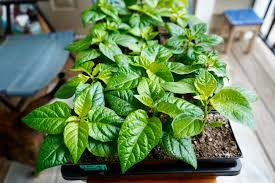

# 📂 **Step 15 – Mount Drive & Auto-Find Saved Files**

We **mounted Google Drive** so Colab can access our stored files.  
Instead of typing the file paths manually, we **automatically searched** for our saved model (`leaf_model.pth`) and class names file (`class_names.json`).  
This makes it easy to **reuse our trained model** without worrying about exact folder locations. 🚀


In [ ]:
# STEP 1 — Mount Drive and find your saved files automatically
import json, torch, os
from pathlib import Path
from google.colab import drive


drive.mount('/content/drive')

SEARCH_ROOT = Path('/content/drive/MyDrive')

pth_candidates = list(SEARCH_ROOT.rglob('leaf_model.pth'))
cls_candidates = list(SEARCH_ROOT.rglob('class_names.json'))

print("🔎 Found model file(s):")
for p in pth_candidates: print(" -", p)
print("\n🔎 Found class_names file(s):")
for p in cls_candidates: print(" -", p)

assert pth_candidates, "❌ Could not find leaf_model.pth under MyDrive."
assert cls_candidates, "❌ Could not find class_names.json under MyDrive."

MODEL_PATH = str(pth_candidates[0])
CLASS_PATH = str(cls_candidates[0])

print("\n✅ Using these paths:")
print("MODEL_PATH =", MODEL_PATH)
print("CLASS_PATH =", CLASS_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔎 Found model file(s):
 - /content/drive/MyDrive/leaf_model.pth

🔎 Found class_names file(s):
 - /content/drive/MyDrive/class_names.json

✅ Using these paths:
MODEL_PATH = /content/drive/MyDrive/leaf_model.pth
CLASS_PATH = /content/drive/MyDrive/class_names.json


# 🏷️ **Step 16 – Load Class Names**

We opened the **`class_names.json`** file and loaded the list of all plant classes into memory.  
This will help the model **map prediction results** to actual plant names instead of just showing numeric labels. 🌿


In [ ]:
# STEP 2 — Load the class names from JSON
with open(CLASS_PATH, 'r') as f:
    class_names = json.load(f)

print(f"✅ Loaded {len(class_names)} classes:")
print(class_names)


✅ Loaded 99 classes:
['Aloevera', 'Amla', 'Amruta_Balli', 'Amruthaballi', 'Arali', 'Ashoka', 'Ashwagandha', 'Astma_weed', 'Avacado', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Basale', 'Beans', 'Betel', 'Betel_Nut', 'Bhrami', 'Brahmi', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Curry_Leaf', 'Doddapatre', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Gauva', 'Geranium', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemon_grass', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Nagadali', 'Neem', 'Nelavembu', 'Nerale', 'Nithyapushpa', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Pappaya', 'Parijatha', 'Pea', 'Pepper', 'Pomegranate', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Raktachandini', 

# 🏗️ **Step 17 – Recreate Model Architecture**

We built the **same ResNet18 model structure** we used during training.  
The final layer was set to output **one value per class** (99 in our case) so predictions match our dataset’s categories. 🌱


In [ ]:
# STEP 3 — Recreate the model architecture
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(class_names))  # 99 classes

print("✅ Model architecture created with output size:", len(class_names))


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model architecture created with output size: 99


# 🏗️ **Step 18 – Match Training's Model Design**

We recreated the **same ResNet18 architecture** exactly like during training.  
The **final fully connected block** has:
- 512 neurons with ReLU activation ⚡  
- Dropout to prevent overfitting 💧  
- Final output layer with **one neuron per plant class** 🌿


In [ ]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=False)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, len(class_names))
)

print(model.fc)


Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=512, out_features=99, bias=True)
)


# 📥 **Step 19 – Load Trained Weights for Inference**

We loaded the **saved weights** from our training into the recreated model 🧠.  
Then, we set the model to **evaluation mode** so:
- No further training happens 🚫  
- Dropout and BatchNorm work in **inference mode** 🎯  

Now our model is **ready to make predictions**! 🌿


In [ ]:
# STEP 4 — Load trained weights into the recreated model
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()

print("✅ Trained weights loaded successfully! Model is ready for inference.")


✅ Trained weights loaded successfully! Model is ready for inference.


# 📷 **Step 20 – Upload an Image and Predict the Plant Species**  

We uploaded an image **in real time** ⏳ and applied the **same preprocessing** steps as during training:  
- Resized to **224×224** 🖼️  
- Converted to a **tensor** 📦  
- Normalized pixel values for **better accuracy** 🎯  

Then, we passed it through the **trained model** to get a **prediction** ✅.  
Finally, we displayed the image 📸 along with the **predicted plant name** 🌿✨.


Saving RoseTest.jpg to RoseTest (2).jpg


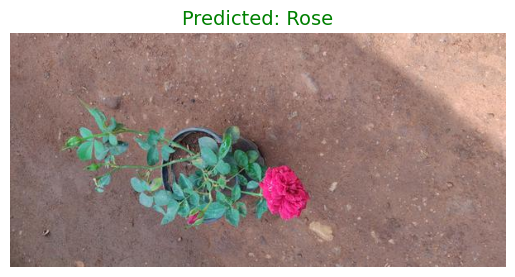

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# STEP 5 — Upload image in real-time
uploaded = files.upload()

# Get uploaded file path
image_path = list(uploaded.keys())[0]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and prepare image
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

# Display image and prediction
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}", fontsize=14, color="green")
plt.show()


Saving HibiscusTest.jpg to HibiscusTest.jpg


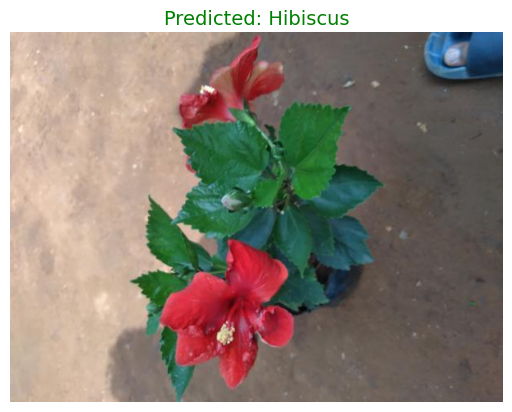

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# STEP 5 — Upload image in real-time
uploaded = files.upload()

# Get uploaded file path
image_path = list(uploaded.keys())[0]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and prepare image
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

# Display image and prediction
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}", fontsize=14, color="green")
plt.show()


Saving GuavaTest.jpg to GuavaTest.jpg


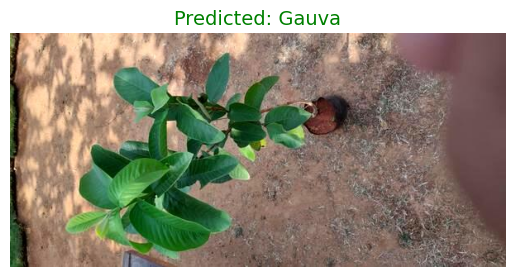

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# STEP 5 — Upload image in real-time
uploaded = files.upload()

# Get uploaded file path
image_path = list(uploaded.keys())[0]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and prepare image
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

# Display image and prediction
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}", fontsize=14, color="green")
plt.show()


Saving TulsiTest.jpg to TulsiTest.jpg


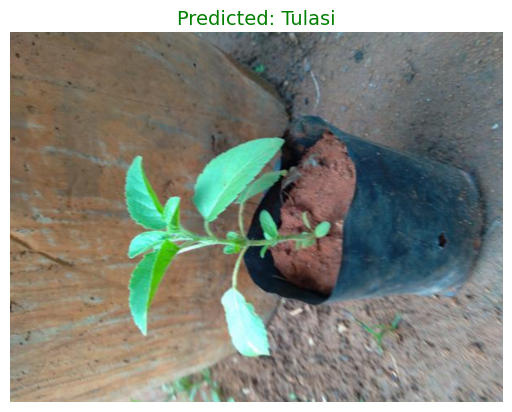

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# STEP 5 — Upload image in real-time
uploaded = files.upload()

# Get uploaded file path
image_path = list(uploaded.keys())[0]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and prepare image
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

# Display image and prediction
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}", fontsize=14, color="green")
plt.show()


Saving MintTest.jpg to MintTest.jpg


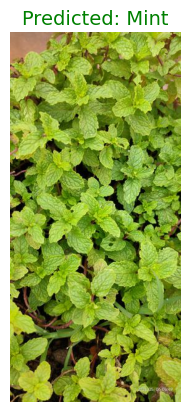

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

# STEP 5 — Upload image in real-time
uploaded = files.upload()

# Get uploaded file path
image_path = list(uploaded.keys())[0]

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load and prepare image
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]

# Display image and prediction
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}", fontsize=14, color="green")
plt.show()
